In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import sklearn
import sklearn.pipeline
import sklearn.preprocessing
import torch
from IPython.core.interactiveshell import InteractiveShell
from sklearn.decomposition import PCA
from sklearn.ensemble import IsolationForest
from sklearn.metrics import accuracy_score, balanced_accuracy_score, confusion_matrix, f1_score, roc_auc_score
from sklearn.svm import OneClassSVM

# from utils.norm import TanhNormalizer
from dataset.dataset import Dataset
from models.autoencoder.vae import VariationalAutoencoder
from utils.metrics import Plot

In [2]:
if InteractiveShell.initialized():
    ipython = InteractiveShell.instance()
    if 'autoreload' not in globals():
        ipython.run_line_magic('load_ext', 'autoreload')
        ipython.run_line_magic('autoreload', '2')
        autoreload = True

In [3]:
dataset_path = 'data/2018/combined/100000.parquet'
dataset = Dataset.from_file(path=dataset_path, random_state=7)
dataset.encode_labels()
dataset.normalize(algorithm=sklearn.pipeline.Pipeline(
    steps=[
        ('qt', sklearn.preprocessing.QuantileTransformer()),
        ('minmax', sklearn.preprocessing.MinMaxScaler())
    ], verbose=False)
)

In [13]:
from umap import UMAP

/home/nvidia/miniconda/envs/ml/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [ ]:
reducer = UMAP()

In [7]:
embedding = reducer.fit_transform(dataset.X_np)
embedding.shape

/opt/miniconda3/lib/python3.11/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.
/opt/miniconda3/lib/python3.11/site-packages/umap/spectral.py:548: UserWarning: Spectral initialisation failed! The eigenvector solver
failed. This is likely due to too small an eigengap. Consider
adding some noise or jitter to your data.

Falling back to random initialisation!
  warn(
/opt/miniconda3/lib/python3.11/site-packages/umap/spectral.py:548: UserWarning: Spectral initialisation failed! The eigenvector solver
failed. This is likely due to too small an eigengap. Consider
adding some noise or jitter to your data.

Falling back to random initialisation!
  warn(
/opt/miniconda3/lib/python3.11/site-packages/umap/spectral.py:548: UserWarning: Spectral initialisation failed! The eigenvector s

(550233, 2)

In [1]:
embedding: np.ndarray
embedding_cls: np.ndarray = np.hstack((embedding, dataset.y_binary_np.reshape(-1, 1))) # type: ignore
embedding0 = embedding_cls[embedding_cls[:, 2] == 0][:, :2]
embedding1 = embedding_cls[embedding_cls[:, 2] == 1][:, :2]

NameError: name 'np' is not defined

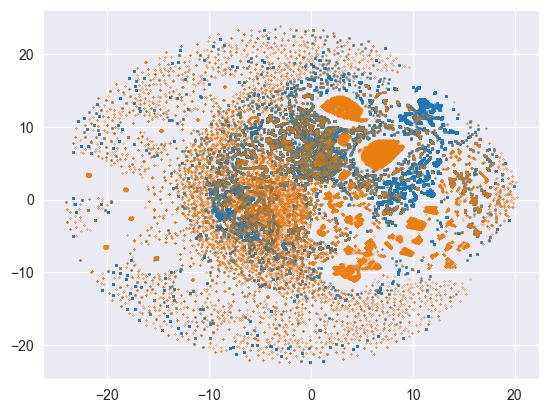

In [35]:
fig, ax=plt.subplots()
ax.scatter(embedding0[:, 0], embedding0[:, 1], s=1, alpha=0.25)
ax.scatter(embedding1[:, 0], embedding1[:, 1], s=0.01, alpha=0.25)
plt.show()

# plt.scatter(
#     embedding[:, 0],
#     embedding[:, 1],
#     c=dataset.y_np)
# plt.gca().set_aspect('equal', 'datalim')
# plt.title('UMAP projection of the Penguin dataset', fontsize=24);

In [5]:
train_dataset, test_dataset = dataset.split(test_size=10)
benign, attacks = train_dataset.label_partition(labels=[1], binary=True)

benign_train, benign_test, benign_val = benign.split(val=True, test_size=40, val_size=10)

benign_train_dl = benign_train.create_data_loader(include_label=False, batch_size=8, shuffle=True, num_workers=8)
benign_test_dl = benign_test.create_data_loader(include_label=False, batch_size=2, shuffle=False)
benign_val_dl = benign_val.create_data_loader(include_label=False, batch_size=2, shuffle=False)

attacks_train, attacks_test, attacks_val = attacks.split(val=True, test_size=40, val_size=10)

attacks_train_dl = attacks_train.create_data_loader(batch_size=2)
attacks_test_dl = attacks_test.create_data_loader(batch_size=2)
attacks_val_dl = attacks_val.create_data_loader(batch_size=2)

In [ ]:
benign_train_dl

In [6]:
# model = Autoencoder(hidden_layers=[128, 64, 32], latent_dim=8)
model = VariationalAutoencoder(hidden_layers=[128, 64, 32], latent_dim=8)

In [7]:
model

VariationalAutoencoder(
  (encoder): Sequential(
    (0): Linear(in_features=71, out_features=128, bias=True)
    (1): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): SiLU()
    (3): Linear(in_features=128, out_features=64, bias=True)
    (4): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): SiLU()
    (6): Linear(in_features=64, out_features=32, bias=True)
    (7): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (8): SiLU()
    (9): Linear(in_features=32, out_features=16, bias=True)
  )
  (decoder): Sequential(
    (0): Linear(in_features=8, out_features=32, bias=True)
    (1): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): SiLU()
    (3): Linear(in_features=32, out_features=64, bias=True)
    (4): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): SiLU()
    (6): Linear(in_features=64, out

In [14]:
from tqdm import tqdm

In [10]:
model = model.to(device='cuda')

In [21]:

optimizer = torch.optim.Adam(model.parameters())

running_loss = 0.0
with tqdm(total=len(benign_train_dl), leave=False) as pbar:
    for _, (inputs,) in enumerate(benign_train_dl):
        # inputs = inputs.to('cuda')  # Move inputs to the specified device
        # optimizer.zero_grad()
        # z, recon, mu, logvar = model(inputs, ret_latent=True)
        # loss = model.vae_loss(recon, inputs, mu, logvar)
        # loss.backward()
        # optimizer.step()
        # running_loss += loss.item()
        pbar.update(1)

# model.eval()
# with torch.no_grad():
#     val_running_loss = 0.0
#     for _, (val_inputs,) in enumerate(benign_val_dl):
#         val_inputs = val_inputs.to('cuda')  # Move validation inputs to the specified device
#         z, val_recon, mu, logvar = model(val_inputs, ret_latent=True)
#         val_running_loss += model.vae_loss(val_recon, val_inputs, mu, logvar).item()
#     val_running_loss_mean = val_running_loss / len(benign_val_dl)

RuntimeError: Caught RuntimeError in DataLoader worker process 0.
Original Traceback (most recent call last):
  File "/home/nvidia/miniconda/envs/ml/lib/python3.12/site-packages/torch/utils/data/_utils/worker.py", line 349, in _worker_loop
    data = fetcher.fetch(index)  # type: ignore[possibly-undefined]
           ^^^^^^^^^^^^^^^^^^^^
  File "/home/nvidia/miniconda/envs/ml/lib/python3.12/site-packages/torch/utils/data/_utils/fetch.py", line 52, in fetch
    data = [self.dataset[idx] for idx in possibly_batched_index]
            ~~~~~~~~~~~~^^^^^
  File "/home/nvidia/miniconda/envs/ml/lib/python3.12/site-packages/torch/utils/data/dataset.py", line 211, in __getitem__
    return tuple(tensor[index] for tensor in self.tensors)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/home/nvidia/miniconda/envs/ml/lib/python3.12/site-packages/torch/utils/data/dataset.py", line 211, in <genexpr>
    return tuple(tensor[index] for tensor in self.tensors)
                 ~~~~~~

In [11]:
model.fit(train_dl=benign_train_dl, val_dl=benign_val_dl, epochs=20)

  0%|          | 0/5625 [00:00<?, ?it/s]

RuntimeError: Caught RuntimeError in DataLoader worker process 0.
Original Traceback (most recent call last):
  File "/home/nvidia/miniconda/envs/ml/lib/python3.12/site-packages/torch/utils/data/_utils/worker.py", line 349, in _worker_loop
    data = fetcher.fetch(index)  # type: ignore[possibly-undefined]
           ^^^^^^^^^^^^^^^^^^^^
  File "/home/nvidia/miniconda/envs/ml/lib/python3.12/site-packages/torch/utils/data/_utils/fetch.py", line 52, in fetch
    data = [self.dataset[idx] for idx in possibly_batched_index]
            ~~~~~~~~~~~~^^^^^
  File "/home/nvidia/miniconda/envs/ml/lib/python3.12/site-packages/torch/utils/data/dataset.py", line 211, in __getitem__
    return tuple(tensor[index] for tensor in self.tensors)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/home/nvidia/miniconda/envs/ml/lib/python3.12/site-packages/torch/utils/data/dataset.py", line 211, in <genexpr>
    return tuple(tensor[index] for tensor in self.tensors)
                 ~~~~~~

In [17]:
# model_attack = Autoencoder(hidden_layers=[256, 128, 64, 32], latent_dim=8)

In [ ]:
# model_attack.fit(train_dl=benign_train_dl, val_dl=benign_val_dl, epochs=20)

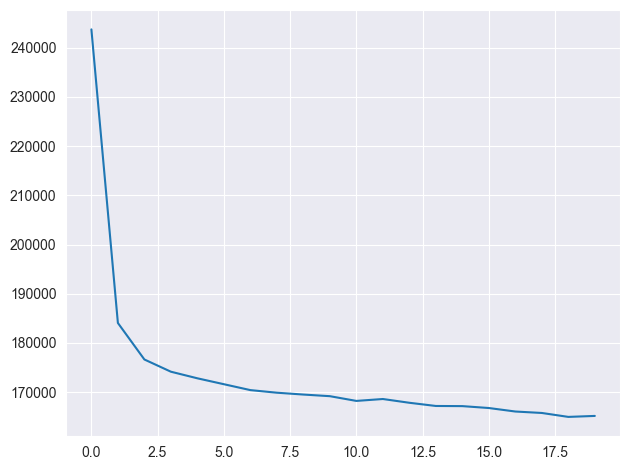

In [41]:
Plot().loss(losses=model.losses)

In [ ]:
# torch.save(model, 'weights_128_64_32_8.pt')

In [43]:
model

VariationalAutoencoder(
  (encoder): Sequential(
    (0): Linear(in_features=71, out_features=128, bias=True)
    (1): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): SiLU()
    (3): Linear(in_features=128, out_features=64, bias=True)
    (4): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): SiLU()
    (6): Linear(in_features=64, out_features=32, bias=True)
    (7): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (8): SiLU()
    (9): Linear(in_features=32, out_features=16, bias=True)
  )
  (decoder): Sequential(
    (0): Linear(in_features=8, out_features=32, bias=True)
    (1): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): SiLU()
    (3): Linear(in_features=32, out_features=64, bias=True)
    (4): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): SiLU()
    (6): Linear(in_features=64, out

In [42]:
latent_layer_benign_test = model.predict_latent(benign_test_dl)
latent_layer_benign_val = model.predict_latent(benign_val_dl)
latent_layer_attack = model.predict_latent(attacks_test_dl)

  0%|          | 0/35998 [00:00<?, ?it/s]


RuntimeError: The expanded size of the tensor (8) must match the existing size (16) at non-singleton dimension 1.  Target sizes: [2, 8].  Tensor sizes: [2, 16]

In [12]:
pca = PCA(n_components=2)
pca.fit(np.vstack([latent_layer_benign_test, latent_layer_benign_val, latent_layer_attack]))

PCA(n_components=2)

In [13]:
x1, y1  = zip(*list(pca.transform(np.vstack([latent_layer_benign_test, latent_layer_benign_val]))))
x2, y2  = zip(*list(pca.transform(latent_layer_attack)))

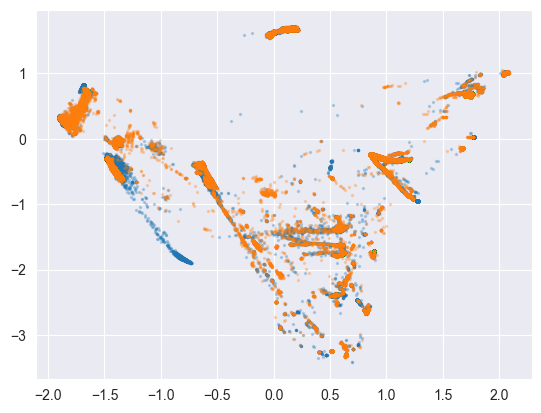

In [14]:
# fig, ax=plt.subplots()
# ax[0].scatter(x2, y2, s=2, alpha=0.25)
# ax[1].scatter(x1, y1, s=2, alpha=0.25)
# plt.show()
fig, ax=plt.subplots()
ax.scatter(x1, y1, s=2, alpha=0.25)
ax.scatter(x2, y2, s=2, alpha=0.25)
plt.show()

In [15]:
iso_forest = IsolationForest(n_estimators=100, random_state=7, max_features=8, contamination=0.5)
svm = OneClassSVM(kernel='linear')

In [16]:
iso_forest.fit(latent_layer_benign_test)

IsolationForest(contamination=0.5, max_features=8, random_state=7)

In [18]:
print(pd.Series(iso_forest.predict(latent_layer_attack)).value_counts())
print(pd.Series(iso_forest.predict(latent_layer_benign_test)).value_counts())

-1    112503
 1     49582
Name: count, dtype: int64
 1    18010
-1    17988
Name: count, dtype: int64


In [ ]:
reco_benign_test = np.array(model.reconstruct(benign_test_dl))
reco_benign_val = np.array(model.reconstruct(benign_val_dl))
reco_attack = np.array(model.reconstruct(attacks_test_dl))

100%|██████████| 35998/35998 [00:03<00:00, 9762.63it/s] 
/var/folders/pp/177jfrrx2_96nn10x7kvzqcc0000gn/T/ipykernel_41089/102042956.py:1: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  reco_benign_test = np.array(model.reconstruct(benign_test_dl))
100%|██████████| 9000/9000 [00:00<00:00, 9987.84it/s] 
/var/folders/pp/177jfrrx2_96nn10x7kvzqcc0000gn/T/ipykernel_41089/102042956.py:2: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  reco_benign_val = np.array(model.reconstruct(beni

IndexError: index 1 is out of bounds for dimension 0 with size 1

In [29]:
reco_loss_benign_test = reco_benign_test - np.array(benign_test_dl.dataset).squeeze()
reco_loss_benign_val = reco_benign_val - np.array(benign_val_dl.dataset).squeeze()
reco_loss_attack = reco_attack - np.array(attacks_dl.dataset).squeeze()


In [65]:
iso_forest.fit(reco_loss_benign_test)

IsolationForest(contamination=0.5, max_features=8, random_state=7)

In [66]:
print(pd.Series(iso_forest.predict(reco_loss_benign_val)).value_counts())

 1    4511
-1    4489
Name: count, dtype: int64


In [67]:
print(pd.Series(iso_forest.predict(reco_loss_attack)).value_counts())

-1    313180
 1     92034
Name: count, dtype: int64


In [45]:
pca = PCA(n_components=2)
pca.fit(dataset.X_np)

PCA(n_components=2)

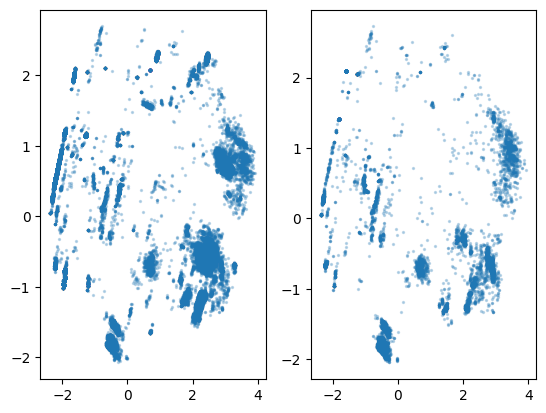

In [50]:
b, a = dataset.label_partition(labels=[1], binary=True)

x1, y1  = zip(*list(pca.transform(b.X_np)))
x2, y2  = zip(*list(pca.transform(a.X_np)))

fig, ax=plt.subplots(ncols=2)
ax[0].scatter(x2, y2, s=2, alpha=0.25)
ax[1].scatter(x1, y1, s=2, alpha=0.25)
plt.show()
# fig, ax=plt.subplots()
# ax.scatter(x1, y1, s=2, alpha=0.25)
# ax.scatter(x2, y2, s=2, alpha=0.25)
plt.show()

In [52]:
b

name: init.special(0)
+-----------------+----------------+----------------+-------------------+-------------------+-------------------+-------------------+--------------------+-------------------+-------------------+-------------------+--------------------+-------------------+---------------+---------------+-----------------+----------------+----------------+----------------+---------------+----------------+---------------+---------------+---------------+---------------+----------------+---------------+---------------+---------------+-----------------+-----------------+------------------+------------------+--------------+--------------+---------------+---------------+----------------+---------------+---------------+----------------+----------------+----------------+----------------+----------------+----------------+------------------+----------------+-----------------+----------------+--------------------+--------------------+--------------------+--------------------+------------------